# Imports & Config

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from torchvision import models

# Set seed for reproducibility
torch.manual_seed(42)

# Config
DATA_DIR = "cropped_cnn_dataset"
CLASSES = ["left", "right"]
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 3
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dataset

In [2]:
class SimpleSignDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        for label, class_name in enumerate(CLASSES):
            folder = os.path.join(root_dir, class_name)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg', '.png')):
                    self.data.append((os.path.join(folder, fname), label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img) / 255.0
        img = torch.tensor(img, dtype=torch.float).permute(2, 0, 1)
        return img, label


# Prepare Data

In [3]:
dataset = SimpleSignDataset(DATA_DIR)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)


# Load Pretrained ResNet18

In [5]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))  # Output layer: 2 classes
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)


# Training with Early Stopping

In [6]:
best_val_loss = float('inf')
early_stop_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        best_model_state = model.state_dict()
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    scheduler.step(avg_val_loss)

# Restore best model
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "resnet18_left_right_best.pth")
print("✅ Training done. Best model saved.")


C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)


Epoch 1: Train Loss=0.2362, Val Loss=0.0864, Val Acc=0.9649


C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)


Epoch 2: Train Loss=0.0355, Val Loss=0.0834, Val Acc=0.9605


C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)


Epoch 3: Train Loss=0.0244, Val Loss=0.1331, Val Acc=0.9561


C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)


Epoch 4: Train Loss=0.0090, Val Loss=0.1131, Val Acc=0.9693


C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)
C:\Users\Msys\AppData\Local\Temp\ipykernel_10060\3307636321.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  images, labels = images.to(DEVICE), torch.tensor(labels).to(DEVICE)


Epoch 5: Train Loss=0.0030, Val Loss=0.1183, Val Acc=0.9605
🛑 Early stopping triggered.
✅ Training done. Best model saved.


# Evaluation

In [7]:
print("📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASSES))


📊 Classification Report:

              precision    recall  f1-score   support

        left       0.98      0.94      0.96       118
       right       0.94      0.98      0.96       110

    accuracy                           0.96       228
   macro avg       0.96      0.96      0.96       228
weighted avg       0.96      0.96      0.96       228



In [10]:
import matplotlib.pyplot as plt

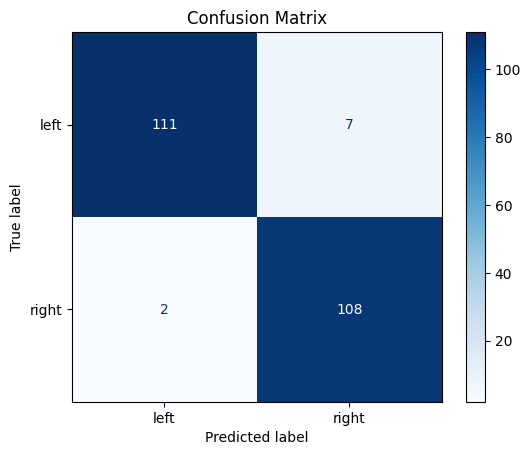

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# # Loss plot
# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.plot(train_losses, label='Train Loss')
# plt.plot(val_losses, label='Val Loss')
# plt.title("Loss Over Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend()

# # Accuracy plot
# plt.subplot(1, 2, 2)
# plt.plot(val_accuracies, label='Val Accuracy', color='green')
# plt.title("Validation Accuracy Over Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()

# plt.tight_layout()
# plt.show()
